In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
RAW_DIR = os.path.join(PROJECT_DIR, "data/raw/dfdc_train_part_00")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")

CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")
AUDIO_DIR = os.path.join(PROCESSED_DIR, "audio")
TEXT_DIR = os.path.join(PROCESSED_DIR, "text")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")
UNCERTAIN_DIR = os.path.join(OUTPUT_DIR, "uncertain_samples")

for folder in [CSV_DIR, FRAMES_DIR, AUDIO_DIR, TEXT_DIR, MODEL_DIR, GRAPH_DIR, REPORT_DIR, PRED_DIR, EXPLAIN_DIR, UNCERTAIN_DIR]:
    os.makedirs(folder, exist_ok=True)

print("All folders are ready.")

All folders are ready.


In [4]:
import os
import json
import cv2
import librosa
import joblib
!pip install -q openai-whisper
import whisper
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("Libraries imported.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 49.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Libraries imported.


In [11]:
import os
import json
import pandas as pd

metadata_path = os.path.join(RAW_DIR, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

df = pd.DataFrame.from_dict(metadata, orient="index")
df.reset_index(inplace=True)
df.rename(columns={"index": "filename"}, inplace=True)

df["video_path"] = df["filename"].apply(lambda x: os.path.join(RAW_DIR, x))

print(df.head())
print(df.columns)
print(df["label"].value_counts())


         filename label  split        original  \
0  owxbbpjpch.mp4  FAKE  train  wynotylpnm.mp4   
1  vpmyeepbep.mp4  REAL  train             NaN   
2  fzvpbrzssi.mp4  REAL  train             NaN   
3  htorvhbcae.mp4  FAKE  train  wclvkepakb.mp4   
4  fckxaqjbxk.mp4  FAKE  train  vpmyeepbep.mp4   

                                          video_path  
0  /content/drive/MyDrive/Deepfake_Project/data/r...  
1  /content/drive/MyDrive/Deepfake_Project/data/r...  
2  /content/drive/MyDrive/Deepfake_Project/data/r...  
3  /content/drive/MyDrive/Deepfake_Project/data/r...  
4  /content/drive/MyDrive/Deepfake_Project/data/r...  
Index(['filename', 'label', 'split', 'original', 'video_path'], dtype='object')
label
FAKE    1248
REAL      86
Name: count, dtype: int64


In [12]:
metadata_csv = os.path.join(CSV_DIR, "metadata_part00.csv")
df.to_csv(metadata_csv, index=False)
print("Saved:", metadata_csv)

Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/metadata_part00.csv


In [13]:
real_df = df[df["label"] == "REAL"].sample(80, random_state=42)
fake_df = df[df["label"] == "FAKE"].sample(80, random_state=42)

sample_df = pd.concat([real_df, fake_df]).sample(frac=1, random_state=42).reset_index(drop=True)

sample_csv = os.path.join(CSV_DIR, "sample_160_videos.csv")
sample_df.to_csv(sample_csv, index=False)

print(sample_df["label"].value_counts())
print("Total videos:", len(sample_df))
print("Saved:", sample_csv)
sample_df.head()

label
FAKE    80
REAL    80
Name: count, dtype: int64
Total videos: 160
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/sample_160_videos.csv


,filename,label,split,original,video_path
0,kxhwssipyi.mp4,FAKE,train,sttnfyptum.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...
1,ratscdfvdk.mp4,FAKE,train,ddtbarpcgo.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...
2,lxnqzocgaq.mp4,FAKE,train,xjzkfqddyk.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...
3,xchzardbfa.mp4,REAL,train,NaN,/content/drive/MyDrive/Deepfake_Project/data/r...
4,iocjgjemeb.mp4,FAKE,train,sttnfyptum.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...


In [14]:
from sklearn.model_selection import train_test_split

sample_df["label"] = sample_df["label"].str.upper()
sample_df["label_num"] = sample_df["label"].map({"REAL": 1, "FAKE": 0})

train_df, temp_df = train_test_split(
    sample_df,
    test_size=0.30,
    random_state=42,
    stratify=sample_df["label_num"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_num"]
)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

final_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

split_csv = os.path.join(CSV_DIR, "sample_160_split.csv")
final_df.to_csv(split_csv, index=False)

print(final_df["split"].value_counts())
print(final_df.groupby(["split", "label"]).size())
print("Saved:", split_csv)

split
train    112
val       24
test      24
Name: count, dtype: int64
split  label
test   FAKE     12
       REAL     12
train  FAKE     56
       REAL     56
val    FAKE     12
       REAL     12
dtype: int64
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/sample_160_split.csv


In [15]:
import cv2
from tqdm.notebook import tqdm

IMG_SIZE = 224
NUM_FRAMES_PER_VIDEO = 10

def extract_frames(video_path, output_folder, num_frames=10, size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)

    existing = [f for f in os.listdir(output_folder) if f.endswith(".jpg")]
    if len(existing) >= num_frames:
        return [
            os.path.join(output_folder, f)
            for f in sorted(existing)[:num_frames]
        ]

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved_paths = []

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.resize(frame, size)

        frame_path = os.path.join(output_folder, f"frame_{i:03d}.jpg")
        cv2.imwrite(frame_path, frame)

        saved_paths.append(frame_path)

    cap.release()
    return saved_paths

In [16]:
final_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_split.csv"))

frame_rows = []

for _, row in tqdm(final_df.iterrows(), total=len(final_df)):
    video_name = row["filename"]
    video_id = Path(video_name).stem

    output_folder = os.path.join(
        FRAMES_DIR,
        row["split"],
        row["label"],
        video_id
    )

    frame_paths = extract_frames(
        row["video_path"],
        output_folder,
        num_frames=NUM_FRAMES_PER_VIDEO,
        size=(IMG_SIZE, IMG_SIZE)
    )

    for frame_path in frame_paths:
        frame_rows.append({
            "filename": video_name,
            "frame_path": frame_path,
            "label": row["label"],
            "label_num": row["label_num"],
            "split": row["split"],
            "video_path": row["video_path"]
        })

frame_df = pd.DataFrame(frame_rows)

frame_csv = os.path.join(CSV_DIR, "sample_160_frames.csv")
frame_df.to_csv(frame_csv, index=False)

print(frame_df.head())
print(frame_df["split"].value_counts())
print(frame_df.groupby(["split", "label"]).size())
print("Saved:", frame_csv)

  0%|          | 0/160 [00:00<?, ?it/s]

         filename                                         frame_path label  \
0  lnhkjhyhvw.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...  REAL   
1  lnhkjhyhvw.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...  REAL   
2  lnhkjhyhvw.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...  REAL   
3  lnhkjhyhvw.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...  REAL   
4  lnhkjhyhvw.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...  REAL   

   label_num  split                                         video_path  
0          1  train  /content/drive/MyDrive/Deepfake_Project/data/r...  
1          1  train  /content/drive/MyDrive/Deepfake_Project/data/r...  
2          1  train  /content/drive/MyDrive/Deepfake_Project/data/r...  
3          1  train  /content/drive/MyDrive/Deepfake_Project/data/r...  
4          1  train  /content/drive/MyDrive/Deepfake_Project/data/r...  
split
train    1120
val       240
test      240
Name: count, dtype: int64
split  label
test  

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

frame_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_frames.csv"))

train_frames = frame_df[frame_df["split"] == "train"]
val_frames = frame_df[frame_df["split"] == "val"]

BATCH_SIZE = 16
EPOCHS = 10

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_frames,
    x_col="frame_path",
    y_col="label_num",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_frames,
    x_col="frame_path",
    y_col="label_num",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1120 validated image filenames.
Found 240 validated image filenames.


In [18]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation="sigmoid")(x)

visual_model = Model(inputs=base_model.input, outputs=output)

visual_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

visual_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
visual_model_path = os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        visual_model_path,
        monitor="val_loss",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )
]

history = visual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Visual model saved:", visual_model_path)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 846s 12s/step - accuracy: 0.5143 - loss: 0.8035 - val_accuracy: 0.4583 - val_loss: 0.7481 - learning_rate: 1.0000e-04
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step - accuracy: 0.5054 - loss: 0.7642 - val_accuracy: 0.5167 - val_loss: 0.7312 - learning_rate: 1.0000e-04
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.5241 - loss: 0.7574 - val_accuracy: 0.5167 - val_loss: 0.7109 - learning_rate: 1.0000e-04
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.5321 - loss: 0.7390 - val_accuracy: 0.5125 - val_loss: 0.6950 - learning_rate: 1.0000e-04
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.5321 - loss: 0.7383 - val_accuracy: 0.5500 - val_loss: 0.6857 - learning_rate: 1.0000e-04
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 208ms/step - accuracy: 0.5652 - loss: 0.7153 - val_accuracy: 0.5708 - val_loss: 0.6818 - learning_rate: 1.0000e-04
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accu

In [20]:
visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

def load_frame(frame_path):
    img = tf.keras.utils.load_img(frame_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    return arr

test_frames = frame_df[frame_df["split"] == "test"]

visual_rows = []

for filename, group in tqdm(test_frames.groupby("filename")):
    frame_paths = group["frame_path"].tolist()

    X = np.stack([load_frame(p) for p in frame_paths])

    preds = visual_model.predict(X, verbose=0).reshape(-1)

    visual_score = float(np.mean(preds))

    visual_rows.append({
        "filename": filename,
        "visual_score": visual_score
    })

visual_scores_df = pd.DataFrame(visual_rows)

visual_score_csv = os.path.join(PRED_DIR, "visual_scores_sample160.csv")
visual_scores_df.to_csv(visual_score_csv, index=False)

print(visual_scores_df.head())
print("Saved:", visual_score_csv)

  0%|          | 0/24 [00:00<?, ?it/s]

         filename  visual_score
0  alnkzqihau.mp4      0.288515
1  apvzjkvnwn.mp4      0.653570
2  exseruhiuk.mp4      0.418237
3  fnslimfagb.mp4      0.331162
4  gfkdvulbfo.mp4      0.533674
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/visual_scores_sample160.csv


In [21]:
import subprocess

def extract_audio(video_path, wav_path):
    if os.path.exists(wav_path) and os.path.getsize(wav_path) > 1000:
        return True

    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        "-acodec", "pcm_s16le",
        wav_path
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    return result.returncode == 0 and os.path.exists(wav_path)

In [22]:
audio_rows = []

for _, row in tqdm(final_df.iterrows(), total=len(final_df)):
    video_id = Path(row["filename"]).stem
    wav_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")

    has_audio = extract_audio(row["video_path"], wav_path)

    audio_rows.append({
        "filename": row["filename"],
        "wav_path": wav_path if has_audio else "",
        "has_audio": has_audio,
        "label": row["label"],
        "label_num": row["label_num"],
        "split": row["split"],
        "video_path": row["video_path"]
    })

audio_df = pd.DataFrame(audio_rows)

audio_csv = os.path.join(CSV_DIR, "sample_160_audio.csv")
audio_df.to_csv(audio_csv, index=False)

print(audio_df.head())
print(audio_df["has_audio"].value_counts())
print("Saved:", audio_csv)

  0%|          | 0/160 [00:00<?, ?it/s]

         filename                                           wav_path  \
0  lnhkjhyhvw.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...   
1  dvrnrzlqdo.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...   
2  jdfaxqtpjk.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...   
3  jjxzidyitl.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...   
4  xkfliqnmwt.mp4  /content/drive/MyDrive/Deepfake_Project/data/p...   

   has_audio label  label_num  split  \
0       True  REAL          1  train   
1       True  FAKE          0  train   
2       True  FAKE          0  train   
3       True  FAKE          0  train   
4       True  REAL          1  train   

                                          video_path  
0  /content/drive/MyDrive/Deepfake_Project/data/r...  
1  /content/drive/MyDrive/Deepfake_Project/data/r...  
2  /content/drive/MyDrive/Deepfake_Project/data/r...  
3  /content/drive/MyDrive/Deepfake_Project/data/r...  
4  /content/drive/MyDrive/Deepfake_Project/data/r..

In [23]:
import librosa

def extract_mfcc_features(wav_path, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=16000)

        if len(y) < sr * 0.5:
            return None

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        features = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1)
        ])

        return features

    except:
        return None

In [24]:
audio_feature_rows = []

for _, row in tqdm(audio_df.iterrows(), total=len(audio_df)):
    if row["has_audio"] == True:
        features = extract_mfcc_features(row["wav_path"])

        if features is not None:
            item = {
                "filename": row["filename"],
                "label": row["label"],
                "label_num": row["label_num"],
                "split": row["split"]
            }

            for i, value in enumerate(features):
                item[f"mfcc_{i}"] = value

            audio_feature_rows.append(item)

audio_feature_df = pd.DataFrame(audio_feature_rows)

audio_feature_csv = os.path.join(CSV_DIR, "sample_160_mfcc_features.csv")
audio_feature_df.to_csv(audio_feature_csv, index=False)

print(audio_feature_df.head())
print("Saved:", audio_feature_csv)

  0%|          | 0/160 [00:00<?, ?it/s]

         filename label  label_num  split      mfcc_0      mfcc_1     mfcc_2  \
0  lnhkjhyhvw.mp4  REAL          1  train -424.253448   93.309792  22.357830   
1  dvrnrzlqdo.mp4  FAKE          0  train -462.129181  105.123550  29.211718   
2  jdfaxqtpjk.mp4  FAKE          0  train -448.703888  105.360100  23.779131   
3  jjxzidyitl.mp4  FAKE          0  train -476.622955   86.361313  21.860466   
4  xkfliqnmwt.mp4  REAL          1  train -425.421478   79.773384   2.918716   

      mfcc_3     mfcc_4    mfcc_5  ...    mfcc_16    mfcc_17    mfcc_18  \
0  27.956657  -3.860090  1.612012  ...  17.089970  15.155035  12.346094   
1  29.375500   0.669840  5.400253  ...  17.066710  14.287336  10.096909   
2  26.161009  -0.642048  6.647483  ...  18.949253  13.460201  11.076050   
3  26.895685  -8.655335 -0.906037  ...  15.863960  14.133286  12.477080   
4  17.939457 -14.093846 -8.186461  ...  17.385786  16.041262  13.359253   

     mfcc_19    mfcc_20    mfcc_21   mfcc_22   mfcc_23   mfcc_24   m

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

audio_feature_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_mfcc_features.csv"))

feature_cols = [col for col in audio_feature_df.columns if col.startswith("mfcc_")]

train_audio = audio_feature_df[audio_feature_df["split"] == "train"]
val_audio = audio_feature_df[audio_feature_df["split"] == "val"]
test_audio = audio_feature_df[audio_feature_df["split"] == "test"].copy()

X_train_audio = train_audio[feature_cols]
y_train_audio = train_audio["label_num"]

X_val_audio = val_audio[feature_cols]
y_val_audio = val_audio["label_num"]

audio_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

audio_model.fit(X_train_audio, y_train_audio)

val_pred = audio_model.predict(X_val_audio)

print(classification_report(
    y_val_audio,
    val_pred,
    target_names=["REAL", "FAKE"]
))

audio_model_path = os.path.join(MODEL_DIR, "audio_mfcc_sample160.pkl")
joblib.dump(audio_model, audio_model_path)

print("Audio model saved:", audio_model_path)

              precision    recall  f1-score   support

        REAL       0.64      0.58      0.61        12
        FAKE       0.62      0.67      0.64        12

    accuracy                           0.62        24
   macro avg       0.63      0.62      0.62        24
weighted avg       0.63      0.62      0.62        24

Audio model saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/audio_mfcc_sample160.pkl


In [26]:
audio_model = joblib.load(os.path.join(MODEL_DIR, "audio_mfcc_sample160.pkl"))

fake_index = list(audio_model.classes_).index(1)

test_audio["audio_score"] = audio_model.predict_proba(
    test_audio[feature_cols]
)[:, fake_index]

test_video_list = final_df[final_df["split"] == "test"][["filename"]]

audio_scores_df = test_video_list.merge(
    test_audio[["filename", "audio_score"]],
    on="filename",
    how="left"
)

audio_scores_df["audio_score"] = audio_scores_df["audio_score"].fillna(0.5)

audio_score_csv = os.path.join(PRED_DIR, "audio_scores_sample160.csv")
audio_scores_df.to_csv(audio_score_csv, index=False)

print(audio_scores_df.head())
print("Saved:", audio_score_csv)

         filename  audio_score
0  qnlyrlrnmn.mp4     0.402833
1  lbwzzntrcc.mp4     0.338964
2  yeouperxzc.mp4     0.559792
3  apvzjkvnwn.mp4     0.795659
4  qloyrbpobv.mp4     0.505557
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/audio_scores_sample160.csv


In [27]:
!pip install -q openai-whisper

In [28]:
import whisper

whisper_model = whisper.load_model("tiny")

100%|█████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 82.7MiB/s]


In [29]:
def transcribe_audio(wav_path):
    try:
        if not isinstance(wav_path, str) or wav_path == "" or not os.path.exists(wav_path):
            return ""

        result = whisper_model.transcribe(wav_path, fp16=False)
        return result["text"].strip()

    except:
        return ""

In [30]:
transcript_rows = []

for _, row in tqdm(audio_df.iterrows(), total=len(audio_df)):
    transcript = transcribe_audio(row["wav_path"])

    transcript_rows.append({
        "filename": row["filename"],
        "transcript": transcript,
        "label": row["label"],
        "label_num": row["label_num"],
        "split": row["split"]
    })

transcript_df = pd.DataFrame(transcript_rows)

transcript_csv = os.path.join(TEXT_DIR, "sample_160_transcripts.csv")
transcript_df.to_csv(transcript_csv, index=False)

print(transcript_df.head())
print("Saved:", transcript_csv)

  0%|          | 0/160 [00:00<?, ?it/s]

         filename                                         transcript label  \
0  lnhkjhyhvw.mp4  sort of progressed as time goes on and the gra...  REAL   
1  dvrnrzlqdo.mp4  and it needs to be seen as such. And I believe...  FAKE   
2  jdfaxqtpjk.mp4  very much a part of the artistic movement, esp...  FAKE   
3  jjxzidyitl.mp4  Well, I don't think so. I mean the only time i...  FAKE   
4  xkfliqnmwt.mp4  of times they will not get the proper attentio...  REAL   

   label_num  split  
0          1  train  
1          0  train  
2          0  train  
3          0  train  
4          1  train  
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/sample_160_transcripts.csv


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

transcript_df = pd.read_csv(os.path.join(TEXT_DIR, "sample_160_transcripts.csv"))

transcript_df["transcript"] = transcript_df["transcript"].fillna("")
transcript_df["text_input"] = transcript_df["transcript"].apply(
    lambda x: x if len(x.strip()) > 0 else "no speech"
)

train_text = transcript_df[transcript_df["split"] == "train"]
val_text = transcript_df[transcript_df["split"] == "val"]
test_text = transcript_df[transcript_df["split"] == "test"].copy()

text_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

text_model.fit(train_text["text_input"], train_text["label_num"])

val_text_pred = text_model.predict(val_text["text_input"])

print(classification_report(
    val_text["label_num"],
    val_text_pred,
    target_names=["REAL", "FAKE"]
))

text_model_path = os.path.join(MODEL_DIR, "text_tfidf_sample160.pkl")
joblib.dump(text_model, text_model_path)

print("Text model saved:", text_model_path)

              precision    recall  f1-score   support

        REAL       0.50      0.42      0.45        12
        FAKE       0.50      0.58      0.54        12

    accuracy                           0.50        24
   macro avg       0.50      0.50      0.50        24
weighted avg       0.50      0.50      0.50        24

Text model saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/text_tfidf_sample160.pkl


In [32]:
text_model = joblib.load(os.path.join(MODEL_DIR, "text_tfidf_sample160.pkl"))

fake_index = list(text_model.classes_).index(1)

test_text["text_score"] = text_model.predict_proba(
    test_text["text_input"]
)[:, fake_index]

# If transcript is empty, keep text score neutral
test_text["text_score"] = np.where(
    test_text["transcript"].str.strip() == "",
    0.5,
    test_text["text_score"]
)

text_scores_df = test_text[["filename", "text_score", "transcript"]]

text_score_csv = os.path.join(PRED_DIR, "text_scores_sample160.csv")
text_scores_df.to_csv(text_score_csv, index=False)

print(text_scores_df.head())
print("Saved:", text_score_csv)

           filename  text_score  \
136  qnlyrlrnmn.mp4    0.436644   
137  lbwzzntrcc.mp4    0.448068   
138  yeouperxzc.mp4    0.619436   
139  apvzjkvnwn.mp4    0.581690   
140  qloyrbpobv.mp4    0.513115   

                                            transcript  
136  your family or your loved ones that had turned...  
137  addictive. First of all, study show that they ...  
138  of what is important to us. So I do think that...  
139  and a lot of things that once we start to tear...  
140  requires many of the tools of art such as colo...  
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/text_scores_sample160.csv


In [33]:
visual_scores_df = pd.read_csv(os.path.join(PRED_DIR, "visual_scores_sample160.csv"))
audio_scores_df = pd.read_csv(os.path.join(PRED_DIR, "audio_scores_sample160.csv"))
text_scores_df = pd.read_csv(os.path.join(PRED_DIR, "text_scores_sample160.csv"))

test_base_df = final_df[final_df["split"] == "test"][[
    "filename",
    "video_path",
    "label",
    "label_num"
]].copy()

test_base_df = test_base_df.rename(columns={"label": "true_label"})

fusion_df = test_base_df.merge(visual_scores_df, on="filename", how="left")
fusion_df = fusion_df.merge(audio_scores_df, on="filename", how="left")
fusion_df = fusion_df.merge(text_scores_df, on="filename", how="left")

fusion_df["visual_score"] = fusion_df["visual_score"].fillna(0.5)
fusion_df["audio_score"] = fusion_df["audio_score"].fillna(0.5)
fusion_df["text_score"] = fusion_df["text_score"].fillna(0.5)
fusion_df["transcript"] = fusion_df["transcript"].fillna("")

fusion_df["average_final_score"] = (
    fusion_df["visual_score"] +
    fusion_df["audio_score"] +
    fusion_df["text_score"]
) / 3

fusion_df["weighted_final_score"] = (
    0.60 * fusion_df["visual_score"] +
    0.25 * fusion_df["audio_score"] +
    0.15 * fusion_df["text_score"]
)

fusion_df.head()

,filename,video_path,true_label,label_num,visual_score,audio_score,text_score,transcript,average_final_score,weighted_final_score
0,qnlyrlrnmn.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,0,0.278224,0.402833,0.436644,your family or your loved ones that had turned...,0.372567,0.333139
1,lbwzzntrcc.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,0,0.423396,0.338964,0.448068,"addictive. First of all, study show that they ...",0.403476,0.405989
2,yeouperxzc.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,0,0.707496,0.559792,0.619436,of what is important to us. So I do think that...,0.628908,0.657361
3,apvzjkvnwn.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,REAL,1,0.653570,0.795659,0.581690,and a lot of things that once we start to tear...,0.676973,0.678310
4,qloyrbpobv.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,0,0.535438,0.505557,0.513115,requires many of the tools of art such as colo...,0.518037,0.524619


In [ ]:
def classify_final_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

fusion_df["predicted_label"] = fusion_df["weighted_final_score"].apply(classify_final_score)

In [ ]:
def create_verdict(row):
    if row["predicted_label"] == "UNCERTAIN":
        return "Needs human review"

    if row["predicted_label"] == row["true_label"]:
        return "Correct prediction"

    return "Incorrect prediction"


def create_explanation(row):
    scores = {
        "visual": row["visual_score"],
        "audio": row["audio_score"],
        "text": row["text_score"]
    }

    strongest = max(scores, key=scores.get)
    weakest = min(scores, key=scores.get)

    difference = max(scores.values()) - min(scores.values())

    if row["predicted_label"] == "REAL":
        main_reason = "Final fused score is in the real range."
    elif row["predicted_label"] == "FAKE":
        main_reason = "Final fused score is in the fake range."
    else:
        main_reason = "Final fused score is between real and fake thresholds."

    if difference > 0.40:
        agreement = "The modality scores show high disagreement."
    else:
        agreement = "The modality scores are reasonably consistent."

    return (
        f"{main_reason} Strongest evidence came from {strongest} modality. "
        f"Weakest evidence came from {weakest} modality. {agreement}"
    )


fusion_df["verdict"] = fusion_df.apply(create_verdict, axis=1)
fusion_df["explanation"] = fusion_df.apply(create_explanation, axis=1)

final_prediction_csv = os.path.join(PRED_DIR, "final_multimodal_predictions_sample160.csv")
fusion_df.to_csv(final_prediction_csv, index=False)

print("Saved:", final_prediction_csv)

fusion_df[[
    "filename",
    "true_label",
    "visual_score",
    "audio_score",
    "text_score",
    "average_final_score",
    "weighted_final_score",
    "predicted_label",
    "verdict",
    "explanation"
]].head()

In [ ]:
uncertain_df = fusion_df[fusion_df["predicted_label"] == "UNCERTAIN"]

uncertain_csv = os.path.join(UNCERTAIN_DIR, "uncertain_samples_sample160.csv")
uncertain_df.to_csv(uncertain_csv, index=False)

print("Uncertain samples:", len(uncertain_df))
print("Saved:", uncertain_csv)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

fusion_df["binary_predicted_label"] = np.where(
    fusion_df["weighted_final_score"] >= 0.5,
    "REAL", # Now REAL is 1, so >= 0.5 is REAL
    "FAKE"  # Now FAKE is 0, so < 0.5 is FAKE
)

print("Binary Accuracy:")
print(accuracy_score(fusion_df["true_label"], fusion_df["binary_predicted_label"]))

print("\nBinary Classification Report:")
print(classification_report(
    fusion_df["true_label"],
    fusion_df["binary_predicted_label"],
    labels=["REAL", "FAKE"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    fusion_df["true_label"],
    fusion_df["binary_predicted_label"],
    labels=["REAL", "FAKE"]
))

In [ ]:
certain_df = fusion_df[fusion_df["predicted_label"] != "UNCERTAIN"]

print("Total test videos:", len(fusion_df))
print("Certain predictions:", len(certain_df))
print("Uncertain predictions:", len(fusion_df) - len(certain_df))

if len(certain_df) > 0:
    print(classification_report(
        certain_df["true_label"],
        certain_df["predicted_label"],
        labels=["REAL", "FAKE"]
    ))
else:
    print("No certain predictions available.")

In [ ]:
visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

last_conv_layer_name = None

for layer in reversed(visual_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer:", last_conv_layer_name)

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) == 0:
        return heatmap.numpy()

    heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()


def save_gradcam(frame_path, output_path):
    original_img = cv2.imread(frame_path)

    if original_img is None:
        return False

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(
        img_array,
        visual_model,
        last_conv_layer_name
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(output_path, superimposed_img)

    return True

In [ ]:
frame_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_frames.csv"))
fusion_df = pd.read_csv(os.path.join(PRED_DIR, "final_multimodal_predictions_sample160.csv"))

selected_df = pd.concat([
    fusion_df.sort_values("weighted_final_score", ascending=False).head(3),
    fusion_df.sort_values("weighted_final_score", ascending=True).head(3),
    fusion_df[fusion_df["predicted_label"] == "UNCERTAIN"].head(3)
]).drop_duplicates("filename")

gradcam_rows = []

for _, row in selected_df.iterrows():
    filename = row["filename"]

    video_frames = frame_df[frame_df["filename"] == filename]

    if len(video_frames) == 0:
        continue

    frame_path = video_frames.iloc[0]["frame_path"]

    output_name = f"{Path(filename).stem}_{row['predicted_label']}_gradcam.jpg"
    output_path = os.path.join(EXPLAIN_DIR, output_name)

    success = save_gradcam(frame_path, output_path)

    if success:
        gradcam_rows.append({
            "filename": filename,
            "true_label": row["true_label"],
            "predicted_label": row["predicted_label"],
            "weighted_final_score": row["weighted_final_score"],
            "frame_path": frame_path,
            "gradcam_path": output_path
        })

gradcam_df = pd.DataFrame(gradcam_rows)

gradcam_csv = os.path.join(EXPLAIN_DIR, "gradcam_outputs_sample160.csv")
gradcam_df.to_csv(gradcam_csv, index=False)

print("Saved:", gradcam_csv)
gradcam_df.head()

In [ ]:
import matplotlib.pyplot as plt

if len(gradcam_df) > 0:
    img_path = gradcam_df.iloc[0]["gradcam_path"]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Grad-CAM Explanation")
    plt.show()
else:
    print("No Grad-CAM image generated.")

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tqdm.notebook import tqdm
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# =========================
# 1. LOAD FILES
# =========================

final_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_split.csv"))
frame_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_frames.csv"))

visual_scores_df = pd.read_csv(os.path.join(PRED_DIR, "visual_scores_sample160.csv"))
audio_scores_df = pd.read_csv(os.path.join(PRED_DIR, "audio_scores_sample160.csv"))
text_scores_df = pd.read_csv(os.path.join(PRED_DIR, "text_scores_sample160.csv"))

# Use only test videos
test_base_df = final_df[final_df["split"] == "test"][[
    "filename",
    "video_path",
    "label",
    "label_num"
]].copy()

test_base_df = test_base_df.rename(columns={"label": "true_label"})

# =========================
# 2. MERGE SCORES
# =========================

fusion_df = test_base_df.merge(visual_scores_df, on="filename", how="left")
fusion_df = fusion_df.merge(audio_scores_df, on="filename", how="left")
fusion_df = fusion_df.merge(text_scores_df[["filename", "text_score", "transcript"]], on="filename", how="left")

fusion_df["visual_score"] = fusion_df["visual_score"].fillna(0.5)
fusion_df["audio_score"] = fusion_df["audio_score"].fillna(0.5)
fusion_df["text_score"] = fusion_df["text_score"].fillna(0.5)
fusion_df["transcript"] = fusion_df["transcript"].fillna("")

# =========================
# 3. WEIGHTED FINAL SCORE
# =========================
# Meaning:
# 1 = REAL
# 0 = FAKE

fusion_df["weighted_final_score"] = (
    0.60 * fusion_df["visual_score"] +
    0.25 * fusion_df["audio_score"] +
    0.15 * fusion_df["text_score"]
)

# =========================
# 4. PREDICTED LABEL BASED ON WEIGHTED SCORE
# =========================

def classify_weighted_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

fusion_df["predicted_label"] = fusion_df["weighted_final_score"].apply(classify_weighted_score)

# =========================
# 5. VERDICT
# =========================

def create_verdict(row):
    if row["predicted_label"] == "UNCERTAIN":
        return "Needs human review"

    if row["predicted_label"] == row["true_label"]:
        return "Correct prediction"

    return "Incorrect prediction"

fusion_df["verdict"] = fusion_df.apply(create_verdict, axis=1)

# =========================
# 6. EXPLANATION
# =========================

def create_explanation(row):
    scores = {
        "visual": row["visual_score"],
        "audio": row["audio_score"],
        "text": row["text_score"]
    }

    strongest = max(scores, key=scores.get)
    weakest = min(scores, key=scores.get)
    difference = max(scores.values()) - min(scores.values())

    if row["predicted_label"] == "REAL":
        main_reason = "The weighted final score is in the real range."
    elif row["predicted_label"] == "FAKE":
        main_reason = "The weighted final score is in the fake range."
    else:
        main_reason = "The weighted final score is between real and fake thresholds, so the system marked it as uncertain."

    if difference > 0.40:
        agreement = "The visual, audio, and text scores show high disagreement."
    else:
        agreement = "The visual, audio, and text scores are reasonably consistent."

    return (
        f"{main_reason} Strongest evidence came from the {strongest} modality. "
        f"Weakest evidence came from the {weakest} modality. {agreement}"
    )

fusion_df["explanation"] = fusion_df.apply(create_explanation, axis=1)

# =========================
# 7. LOAD VISUAL MODEL FOR GRAD-CAM
# =========================

IMG_SIZE = 224

visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

last_conv_layer_name = None

for layer in reversed(visual_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer:", last_conv_layer_name)

# =========================
# 8. GRAD-CAM FUNCTIONS
# =========================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path):
    original_img = cv2.imread(frame_path)

    if original_img is None:
        return ""

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(
        img_array,
        visual_model,
        last_conv_layer_name
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(output_path, superimposed_img)

    return output_path

# =========================
# 9. CREATE GRAD-CAM IMAGE FOR EACH TEST VIDEO
# =========================

gradcam_paths = []

for _, row in tqdm(fusion_df.iterrows(), total=len(fusion_df)):
    filename = row["filename"]

    video_frames = frame_df[frame_df["filename"] == filename]

    if len(video_frames) == 0:
        gradcam_paths.append("")
        continue

    # Use first extracted frame of each video
    frame_path = video_frames.iloc[0]["frame_path"]

    output_name = f"{Path(filename).stem}_{row['predicted_label']}_gradcam.jpg"
    output_path = os.path.join(EXPLAIN_DIR, output_name)

    gradcam_image_path = save_gradcam_image(frame_path, output_path)

    gradcam_paths.append(gradcam_image_path)

fusion_df["gradcam_image_path"] = gradcam_paths

# =========================
# 10. FINAL REQUIRED OUTPUT
# =========================

final_result_df = fusion_df[[
    "filename",
    "weighted_final_score",
    "true_label",
    "predicted_label",
    "verdict",
    "explanation",
    "gradcam_image_path"
]].copy()

final_result_csv = os.path.join(
    PRED_DIR,
    "final_score_with_gradcam_sample160.csv"
)

final_result_df.to_csv(final_result_csv, index=False)

print("Final CSV saved:", final_result_csv)

final_result_df.head(20)

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tqdm.notebook import tqdm
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# =========================
# 1. LOAD FILES
# =========================

final_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_split.csv"))
frame_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_frames.csv"))

visual_scores_df = pd.read_csv(os.path.join(PRED_DIR, "visual_scores_sample160.csv"))
audio_scores_df = pd.read_csv(os.path.join(PRED_DIR, "audio_scores_sample160.csv"))
text_scores_df = pd.read_csv(os.path.join(PRED_DIR, "text_scores_sample160.csv"))

# Use only test videos
test_base_df = final_df[final_df["split"] == "test"][[
    "filename",
    "video_path",
    "label",
    "label_num"
]].copy()

test_base_df = test_base_df.rename(columns={"label": "true_label"})

# =========================
# 2. MERGE SCORES
# =========================

fusion_df = test_base_df.merge(visual_scores_df, on="filename", how="left")
fusion_df = fusion_df.merge(audio_scores_df, on="filename", how="left")
fusion_df = fusion_df.merge(
    text_scores_df[["filename", "text_score", "transcript"]],
    on="filename",
    how="left"
)

fusion_df["visual_score"] = fusion_df["visual_score"].fillna(0.5)
fusion_df["audio_score"] = fusion_df["audio_score"].fillna(0.5)
fusion_df["text_score"] = fusion_df["text_score"].fillna(0.5)
fusion_df["transcript"] = fusion_df["transcript"].fillna("")

# =========================
# 3. AVERAGE FINAL SCORE
# =========================

fusion_df["average_final_score"] = (
    fusion_df["visual_score"] +
    fusion_df["audio_score"] +
    fusion_df["text_score"]
) / 3

# =========================
# 4. PREDICTED LABEL BASED ON AVERAGE SCORE
# =========================

def classify_average_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

fusion_df["predicted_label"] = fusion_df["average_final_score"].apply(classify_average_score)

# =========================
# 5. VERDICT
# =========================

def create_verdict(row):
    if row["predicted_label"] == "UNCERTAIN":
        return "Needs human review"

    if row["predicted_label"] == row["true_label"]:
        return "Correct prediction"

    return "Incorrect prediction"

fusion_df["verdict"] = fusion_df.apply(create_verdict, axis=1)

# =========================
# 6. EXPLANATION
# =========================

def create_explanation(row):
    scores = {
        "visual": row["visual_score"],
        "audio": row["audio_score"],
        "text": row["text_score"]
    }

    strongest = max(scores, key=scores.get)
    weakest = min(scores, key=scores.get)
    difference = max(scores.values()) - min(scores.values())

    if row["predicted_label"] == "REAL":
        main_reason = "The averaged final score is in the real range."
    elif row["predicted_label"] == "FAKE":
        main_reason = "The averaged final score is in the fake range."
    else:
        main_reason = "The averaged final score is between real and fake thresholds, so the system marked it as uncertain."

    if difference > 0.40:
        agreement = "The visual, audio, and text scores show high disagreement."
    else:
        agreement = "The visual, audio, and text scores are reasonably consistent."

    return (
        f"{main_reason} Strongest evidence came from the {strongest} modality. "
        f"Weakest evidence came from the {weakest} modality. {agreement}"
    )

fusion_df["explanation"] = fusion_df.apply(create_explanation, axis=1)

# =========================
# 7. LOAD VISUAL MODEL FOR GRAD-CAM
# =========================

IMG_SIZE = 224

visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

last_conv_layer_name = None

for layer in reversed(visual_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer:", last_conv_layer_name)

# =========================
# 8. GRAD-CAM FUNCTIONS
# =========================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value
    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path):
    original_img = cv2.imread(frame_path)

    if original_img is None:
        return ""

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(
        img_array,
        visual_model,
        last_conv_layer_name
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(output_path, superimposed_img)
    return output_path

# =========================
# 9. CREATE GRAD-CAM IMAGE FOR EACH TEST VIDEO
# =========================

gradcam_paths = []

for _, row in tqdm(fusion_df.iterrows(), total=len(fusion_df)):
    filename = row["filename"]

    video_frames = frame_df[frame_df["filename"] == filename]

    if len(video_frames) == 0:
        gradcam_paths.append("")
        continue

    # use first extracted frame
    frame_path = video_frames.iloc[0]["frame_path"]

    output_name = f"{Path(filename).stem}_{row['predicted_label']}_gradcam.jpg"
    output_path = os.path.join(EXPLAIN_DIR, output_name)

    gradcam_image_path = save_gradcam_image(frame_path, output_path)
    gradcam_paths.append(gradcam_image_path)

fusion_df["gradcam_image_path"] = gradcam_paths

# =========================
# 10. FINAL REQUIRED OUTPUT
# =========================

final_result_df = fusion_df[[
    "filename",
    "average_final_score",
    "true_label",
    "predicted_label",
    "verdict",
    "explanation",
    "gradcam_image_path"
]].copy()

final_result_csv = os.path.join(
    PRED_DIR,
    "final_average_score_with_gradcam_sample160.csv"
)

final_result_df.to_csv(final_result_csv, index=False)

print("Final CSV saved:", final_result_csv)
final_result_df.head(20)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create a binary predicted label based on the average_final_score
# Assuming a threshold of 0.5 for binary classification
fusion_df["binary_predicted_label_avg"] = np.where(
    fusion_df["average_final_score"] >= 0.5,
    "REAL", # Now REAL is 1, so >= 0.5 is REAL
    "FAKE"  # Now FAKE is 0, so < 0.5 is FAKE
)

print("\n--- Average Fusion Metrics ---")
print("Binary Accuracy for Average Fusion:")
print(accuracy_score(fusion_df["true_label"], fusion_df["binary_predicted_label_avg"]))

print("\nBinary Classification Report for Average Fusion:")
print(classification_report(
    fusion_df["true_label"],
    fusion_df["binary_predicted_label_avg"],
    labels=["REAL", "FAKE"]
))

print("\nConfusion Matrix for Average Fusion:")
print(confusion_matrix(
    fusion_df["true_label"],
    fusion_df["binary_predicted_label_avg"],
    labels=["REAL", "FAKE"]
))

In [ ]:
# ============================================================
# TEST ONE VIDEO FROM GOOGLE DRIVE
# Multimodal Deepfake Detection:
# Visual = MobileNetV2
# Audio = MFCC
# Text = Whisper + TF-IDF
# Fusion = Average + Weighted
# Explainability = Grad-CAM
# ============================================================

# =========================
# 1. PUT YOUR DRIVE VIDEO PATH HERE
# =========================

EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/trump.mp4"

# Example:
# EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/Deepfake_Project/external_videos/random_video.mp4"

# =========================
# 2. IMPORT LIBRARIES
# =========================

import os
import cv2
import joblib
import librosa
import whisper
import subprocess
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# =========================
# 3. FOLDER STRUCTURE
# =========================

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

external_output_dir = os.path.join(OUTPUT_DIR, "external_test")
external_frame_dir = os.path.join(external_output_dir, "frames")
external_audio_dir = os.path.join(external_output_dir, "audio")
external_gradcam_dir = os.path.join(external_output_dir, "gradcam")

for folder in [
    external_output_dir,
    external_frame_dir,
    external_audio_dir,
    external_gradcam_dir
]:
    os.makedirs(folder, exist_ok=True)

# =========================
# 4. CHECK VIDEO PATH
# =========================

if not os.path.exists(EXTERNAL_VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {EXTERNAL_VIDEO_PATH}")

filename = Path(EXTERNAL_VIDEO_PATH).name
video_id = Path(filename).stem

video_frame_dir = os.path.join(external_frame_dir, video_id)
os.makedirs(video_frame_dir, exist_ok=True)

print("Testing video:", EXTERNAL_VIDEO_PATH)

# =========================
# 5. LOAD TRAINED MODELS
# =========================

IMG_SIZE = 224
NUM_FRAMES_PER_VIDEO = 10

visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

audio_model = joblib.load(
    os.path.join(MODEL_DIR, "audio_mfcc_sample160.pkl")
)

text_model = joblib.load(
    os.path.join(MODEL_DIR, "text_tfidf_sample160.pkl")
)

whisper_model = whisper.load_model("tiny")

print("All trained models loaded successfully.")

# =========================
# 6. EXTRACT FRAMES
# =========================

def extract_frames(video_path, output_folder, num_frames=10, size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved_paths = []

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.resize(frame, size)

        frame_path = os.path.join(output_folder, f"frame_{i:03d}.jpg")
        cv2.imwrite(frame_path, frame)

        saved_paths.append(frame_path)

    cap.release()
    return saved_paths


frame_paths = extract_frames(
    EXTERNAL_VIDEO_PATH,
    video_frame_dir,
    num_frames=NUM_FRAMES_PER_VIDEO,
    size=(IMG_SIZE, IMG_SIZE)
)

print("Extracted frames:", len(frame_paths))

# =========================
# 7. VISUAL SCORE
# =========================

def load_frame_for_prediction(frame_path):
    img = tf.keras.utils.load_img(frame_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    return arr


if len(frame_paths) > 0:
    X_frames = np.stack([load_frame_for_prediction(p) for p in frame_paths])
    visual_preds = visual_model.predict(X_frames, verbose=0).reshape(-1)
    visual_score = float(np.mean(visual_preds))
else:
    visual_score = 0.5

print("Visual Score:", visual_score)

# =========================
# 8. EXTRACT AUDIO
# =========================

def extract_audio(video_path, wav_path):
    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        "-acodec", "pcm_s16le",
        wav_path
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    return result.returncode == 0 and os.path.exists(wav_path) and os.path.getsize(wav_path) > 1000


wav_path = os.path.join(external_audio_dir, f"{video_id}.wav")
has_audio = extract_audio(EXTERNAL_VIDEO_PATH, wav_path)

print("Audio extracted:", has_audio)
print("Audio path:", wav_path)

# =========================
# 9. AUDIO SCORE USING MFCC
# =========================

def extract_mfcc_features(wav_path, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=16000)

        if len(y) < sr * 0.5:
            return None

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        features = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1)
        ])

        return features

    except Exception as e:
        print("MFCC extraction error:", e)
        return None


if has_audio:
    audio_features = extract_mfcc_features(wav_path)

    if audio_features is not None:
        feature_cols = [f"mfcc_{i}" for i in range(len(audio_features))]
        audio_feature_df = pd.DataFrame([audio_features], columns=feature_cols)

        fake_index_audio = list(audio_model.classes_).index(0) # Now FAKE is 0
        audio_score = float(audio_model.predict_proba(audio_feature_df)[:, fake_index_audio][0])
    else:
        audio_score = 0.5
else:
    audio_score = 0.5

print("Audio Score:", audio_score)

# =========================
# 10. TRANSCRIBE AUDIO USING WHISPER
# =========================

def transcribe_audio(wav_path):
    try:
        if not os.path.exists(wav_path):
            return ""

        result = whisper_model.transcribe(wav_path, fp16=False)
        return result["text"].strip()

    except Exception as e:
        print("Whisper transcription error:", e)
        return ""


if has_audio:
    transcript = transcribe_audio(wav_path)
else:
    transcript = ""

print("Transcript:")
print(transcript)

# =========================
# 11. TEXT SCORE USING TF-IDF
# =========================

if transcript.strip() == "":
    text_score = 0.5
    text_input = "no speech"
else:
    text_input = transcript
    fake_index_text = list(text_model.classes_).index(0) # Now FAKE is 0
    text_score = float(text_model.predict_proba([text_input])[:, fake_index_text][0])

print("Text Score:", text_score)

# =========================
# 12. SCORE FUSION
# =========================

average_final_score = (
    visual_score +
    audio_score +
    text_score
) / 3

weighted_final_score = (
    0.60 * visual_score +
    0.25 * audio_score +
    0.15 * text_score
)

print("Average Final Score:", average_final_score)
print("Weighted Final Score:", weighted_final_score)

# =========================
# 13. CLASSIFICATION
# =========================

def classify_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"


predicted_label_average = classify_score(average_final_score)
predicted_label_weighted = classify_score(weighted_final_score)

print("Predicted Label Based on Average Score:", predicted_label_average)
print("Predicted Label Based on Weighted Score:", predicted_label_weighted)

# =========================
# 14. EXPLANATION
# =========================

def create_explanation(visual_score, audio_score, text_score, final_score, predicted_label, method_name):
    scores = {
        "visual": visual_score,
        "audio": audio_score,
        "text": text_score
    }

    strongest = max(scores, key=scores.get)
    weakest = min(scores, key=scores.get)
    difference = max(scores.values()) - min(scores.values())

    if predicted_label == "REAL":
        main_reason = f"The {method_name} final score is in the real range."
    elif predicted_label == "FAKE":
        main_reason = f"The {method_name} final score is in the fake range."
    else:
        main_reason = f"The {method_name} final score is between real and fake thresholds, so the video is marked as uncertain."

    if difference > 0.40:
        agreement = "The visual, audio, and text scores show high disagreement."
    else:
        agreement = "The visual, audio, and text scores are reasonably consistent."

    return (
        f"{main_reason} Strongest evidence came from the {strongest} modality. "
        f"Weakest evidence came from the {weakest} modality. {agreement}"
    )


average_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    average_final_score,
    predicted_label_average,
    "average"
)

weighted_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    weighted_final_score,
    predicted_label_weighted,
    "weighted"
)

verdict = "Drive video tested. True label is unknown, so correctness cannot be verified."

# =========================
# 15. GRAD-CAM
# =========================

last_conv_layer_name = None

for layer in reversed(visual_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer:", last_conv_layer_name)


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value
    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path):
    original_img = cv2.imread(frame_path)

    if original_img is None:
        return ""

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(
        img_array,
        visual_model,
        last_conv_layer_name
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(output_path, superimposed_img)

    return output_path


if len(frame_paths) > 0:
    gradcam_image_path = os.path.join(
        external_gradcam_dir,
        f"{video_id}_{predicted_label_weighted}_gradcam.jpg"
    )

    gradcam_image_path = save_gradcam_image(
        frame_paths[0],
        gradcam_image_path
    )
else:
    gradcam_image_path = ""

print("Grad-CAM Image Path:", gradcam_image_path)

# =========================
# 16. SAVE FINAL RESULT
# =========================

external_result = pd.DataFrame([{
    "filename": filename,
    "video_path": EXTERNAL_VIDEO_PATH,
    "true_label": "UNKNOWN_DRIVE_VIDEO",

    "visual_score": visual_score,
    "audio_score": audio_score,
    "text_score": text_score,

    "average_final_score": average_final_score,
    "predicted_label_based_average_score": predicted_label_average,

    "weighted_final_score": weighted_final_score,
    "predicted_label_based_weighted_score": predicted_label_weighted,

    "verdict": verdict,
    "average_explanation": average_explanation,
    "weighted_explanation": weighted_explanation,

    "gradcam_image_path": gradcam_image_path,
    "transcript": transcript
}])

external_result_csv = os.path.join(
    external_output_dir,
    f"{video_id}_drive_video_test_result.csv"
)

external_result.to_csv(external_result_csv, index=False)

print("Final result saved:")
print(external_result_csv)

display(external_result)

# =========================
# 17. DISPLAY GRAD-CAM IMAGE
# =========================

if gradcam_image_path != "" and os.path.exists(gradcam_image_path):
    img = cv2.imread(gradcam_image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Grad-CAM for Drive Video")
    plt.show()
else:
    print("No Grad-CAM image available.")

In [ ]:
# ============================================================
# TEST ONE VIDEO FROM GOOGLE DRIVE
# Multimodal Deepfake Detection:
# Visual = MobileNetV2
# Audio = MFCC
# Text = Whisper + TF-IDF
# Fusion = Average + Weighted
# Explainability = Grad-CAM
# ============================================================

# =========================
# 1. PUT YOUR DRIVE VIDEO PATH HERE
# =========================

EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/Screen Recording 2026-04-21 142855.mp4"

# Example:
# EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/Deepfake_Project/external_videos/random_video.mp4"

# =========================
# 2. IMPORT LIBRARIES
# =========================

import os
import cv2
import joblib
import librosa
import whisper
import subprocess
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# =========================
# 3. FOLDER STRUCTURE
# =========================

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

external_output_dir = os.path.join(OUTPUT_DIR, "external_test")
external_frame_dir = os.path.join(external_output_dir, "frames")
external_audio_dir = os.path.join(external_output_dir, "audio")
external_gradcam_dir = os.path.join(external_output_dir, "gradcam")

for folder in [
    external_output_dir,
    external_frame_dir,
    external_audio_dir,
    external_gradcam_dir
]:
    os.makedirs(folder, exist_ok=True)

# =========================
# 4. CHECK VIDEO PATH
# =========================

if not os.path.exists(EXTERNAL_VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {EXTERNAL_VIDEO_PATH}")

filename = Path(EXTERNAL_VIDEO_PATH).name
video_id = Path(filename).stem

video_frame_dir = os.path.join(external_frame_dir, video_id)
os.makedirs(video_frame_dir, exist_ok=True)

print("Testing video:", EXTERNAL_VIDEO_PATH)

# =========================
# 5. LOAD TRAINED MODELS
# =========================

IMG_SIZE = 224
NUM_FRAMES_PER_VIDEO = 10

visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

audio_model = joblib.load(
    os.path.join(MODEL_DIR, "audio_mfcc_sample160.pkl")
)

text_model = joblib.load(
    os.path.join(MODEL_DIR, "text_tfidf_sample160.pkl")
)

whisper_model = whisper.load_model("tiny")

print("All trained models loaded successfully.")

# =========================
# 6. EXTRACT FRAMES
# =========================

def extract_frames(video_path, output_folder, num_frames=10, size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved_paths = []

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.resize(frame, size)

        frame_path = os.path.join(output_folder, f"frame_{i:03d}.jpg")
        cv2.imwrite(frame_path, frame)

        saved_paths.append(frame_path)

    cap.release()
    return saved_paths


frame_paths = extract_frames(
    EXTERNAL_VIDEO_PATH,
    video_frame_dir,
    num_frames=NUM_FRAMES_PER_VIDEO,
    size=(IMG_SIZE, IMG_SIZE)
)

print("Extracted frames:", len(frame_paths))

# =========================
# 7. VISUAL SCORE
# =========================

def load_frame_for_prediction(frame_path):
    img = tf.keras.utils.load_img(frame_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    return arr


if len(frame_paths) > 0:
    X_frames = np.stack([load_frame_for_prediction(p) for p in frame_paths])
    visual_preds = visual_model.predict(X_frames, verbose=0).reshape(-1)
    visual_score = float(np.mean(visual_preds))
else:
    visual_score = 0.5

print("Visual Score:", visual_score)

# =========================
# 8. EXTRACT AUDIO
# =========================

def extract_audio(video_path, wav_path):
    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        "-acodec", "pcm_s16le",
        wav_path
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    return result.returncode == 0 and os.path.exists(wav_path) and os.path.getsize(wav_path) > 1000


wav_path = os.path.join(external_audio_dir, f"{video_id}.wav")
has_audio = extract_audio(EXTERNAL_VIDEO_PATH, wav_path)

print("Audio extracted:", has_audio)
print("Audio path:", wav_path)

# =========================
# 9. AUDIO SCORE USING MFCC
# =========================

def extract_mfcc_features(wav_path, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=16000)

        if len(y) < sr * 0.5:
            return None

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        features = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1)
        ])

        return features

    except Exception as e:
        print("MFCC extraction error:", e)
        return None


if has_audio:
    audio_features = extract_mfcc_features(wav_path)

    if audio_features is not None:
        feature_cols = [f"mfcc_{i}" for i in range(len(audio_features))]
        audio_feature_df = pd.DataFrame([audio_features], columns=feature_cols)

        fake_index_audio = list(audio_model.classes_).index(0) # Now FAKE is 0
        audio_score = float(audio_model.predict_proba(audio_feature_df)[:, fake_index_audio][0])
    else:
        audio_score = 0.5
else:
    audio_score = 0.5

print("Audio Score:", audio_score)

# =========================
# 10. TRANSCRIBE AUDIO USING WHISPER
# =========================

def transcribe_audio(wav_path):
    try:
        if not os.path.exists(wav_path):
            return ""

        result = whisper_model.transcribe(wav_path, fp16=False)
        return result["text"].strip()

    except Exception as e:
        print("Whisper transcription error:", e)
        return ""


if has_audio:
    transcript = transcribe_audio(wav_path)
else:
    transcript = ""

print("Transcript:")
print(transcript)

# =========================
# 11. TEXT SCORE USING TF-IDF
# =========================

if transcript.strip() == "":
    text_score = 0.5
    text_input = "no speech"
else:
    text_input = transcript
    fake_index_text = list(text_model.classes_).index(0) # Now FAKE is 0
    text_score = float(text_model.predict_proba([text_input])[:, fake_index_text][0])

print("Text Score:", text_score)

# =========================
# 12. SCORE FUSION
# =========================

average_final_score = (
    visual_score +
    audio_score +
    text_score
) / 3

weighted_final_score = (
    0.60 * visual_score +
    0.25 * audio_score +
    0.15 * text_score
)

print("Average Final Score:", average_final_score)
print("Weighted Final Score:", weighted_final_score)

# =========================
# 13. CLASSIFICATION
# =========================

def classify_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"


predicted_label_average = classify_score(average_final_score)
predicted_label_weighted = classify_score(weighted_final_score)

print("Predicted Label Based on Average Score:", predicted_label_average)
print("Predicted Label Based on Weighted Score:", predicted_label_weighted)

# =========================
# 14. EXPLANATION
# =========================

def create_explanation(visual_score, audio_score, text_score, final_score, predicted_label, method_name):
    scores = {
        "visual": visual_score,
        "audio": audio_score,
        "text": text_score
    }

    strongest = max(scores, key=scores.get)
    weakest = min(scores, key=scores.get)
    difference = max(scores.values()) - min(scores.values())

    if predicted_label == "REAL":
        main_reason = f"The {method_name} final score is in the real range."
    elif predicted_label == "FAKE":
        main_reason = f"The {method_name} final score is in the fake range."
    else:
        main_reason = f"The {method_name} final score is between real and fake thresholds, so the video is marked as uncertain."

    if difference > 0.40:
        agreement = "The visual, audio, and text scores show high disagreement."
    else:
        agreement = "The visual, audio, and text scores are reasonably consistent."

    return (
        f"{main_reason} Strongest evidence came from the {strongest} modality. "
        f"Weakest evidence came from the {weakest} modality. {agreement}"
    )


average_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    average_final_score,
    predicted_label_average,
    "average"
)

weighted_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    weighted_final_score,
    predicted_label_weighted,
    "weighted"
)

verdict = "Drive video tested. True label is unknown, so correctness cannot be verified."

# =========================
# 15. GRAD-CAM
# =========================

last_conv_layer_name = None

for layer in reversed(visual_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer:", last_conv_layer_name)


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value
    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path):
    original_img = cv2.imread(frame_path)

    if original_img is None:
        return ""

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(
        img_array,
        visual_model,
        last_conv_layer_name
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(output_path, superimposed_img)

    return output_path


if len(frame_paths) > 0:
    gradcam_image_path = os.path.join(
        external_gradcam_dir,
        f"{video_id}_{predicted_label_weighted}_gradcam.jpg"
    )

    gradcam_image_path = save_gradcam_image(
        frame_paths[0],
        gradcam_image_path
    )
else:
    gradcam_image_path = ""

print("Grad-CAM Image Path:", gradcam_image_path)

# =========================
# 16. SAVE FINAL RESULT
# =========================

external_result = pd.DataFrame([{
    "filename": filename,
    "video_path": EXTERNAL_VIDEO_PATH,
    "true_label": "UNKNOWN_DRIVE_VIDEO",

    "visual_score": visual_score,
    "audio_score": audio_score,
    "text_score": text_score,

    "average_final_score": average_final_score,
    "predicted_label_based_average_score": predicted_label_average,

    "weighted_final_score": weighted_final_score,
    "predicted_label_based_weighted_score": predicted_label_weighted,

    "verdict": verdict,
    "average_explanation": average_explanation,
    "weighted_explanation": weighted_explanation,

    "gradcam_image_path": gradcam_image_path,
    "transcript": transcript
}])

external_result_csv = os.path.join(
    external_output_dir,
    f"{video_id}_drive_video_test_result.csv"
)

external_result.to_csv(external_result_csv, index=False)

print("Final result saved:")
print(external_result_csv)

display(external_result)

# =========================
# 17. DISPLAY GRAD-CAM IMAGE
# =========================

if gradcam_image_path != "" and os.path.exists(gradcam_image_path):
    img = cv2.imread(gradcam_image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Grad-CAM for Drive Video")
    plt.show()
else:
    print("No Grad-CAM image available.")

### Test a video from the Raw Data

In [ ]:
import os
import cv2
import joblib
import librosa
import whisper
import subprocess
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# =========================
# 1. SELECT A VIDEO FROM RAW DATASET
# =========================

# Load final_df to get video paths from the original raw data
final_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_split.csv"))

# Selecting the first video from the training set as an example
EXTERNAL_VIDEO_PATH = final_df[final_df["split"] == "train"].iloc[0]["video_path"]

# =========================
# 2. IMPORT LIBRARIES (Already imported, but keeping for standalone execution)
# =========================

# =========================
# 3. FOLDER STRUCTURE
# =========================

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

external_output_dir = os.path.join(OUTPUT_DIR, "external_test")
external_frame_dir = os.path.join(external_output_dir, "frames")
external_audio_dir = os.path.join(external_output_dir, "audio")
external_gradcam_dir = os.path.join(external_output_dir, "gradcam")

for folder in [
    external_output_dir,
    external_frame_dir,
    external_audio_dir,
    external_gradcam_dir
]:
    os.makedirs(folder, exist_ok=True)

# =========================
# 4. CHECK VIDEO PATH
# =========================

if not os.path.exists(EXTERNAL_VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {EXTERNAL_VIDEO_PATH}")

filename = Path(EXTERNAL_VIDEO_PATH).name
video_id = Path(filename).stem

video_frame_dir = os.path.join(external_frame_dir, video_id)
os.makedirs(video_frame_dir, exist_ok=True)

print("Testing video:", EXTERNAL_VIDEO_PATH)

# =========================
# 5. LOAD TRAINED MODELS
# =========================

IMG_SIZE = 224
NUM_FRAMES_PER_VIDEO = 10

visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

audio_model = joblib.load(
    os.path.join(MODEL_DIR, "audio_mfcc_sample160.pkl")
)

text_model = joblib.load(
    os.path.join(MODEL_DIR, "text_tfidf_sample160.pkl")
)

whisper_model = whisper.load_model("tiny")

print("All trained models loaded successfully.")

# =========================
# 6. EXTRACT FRAMES
# =========================

def extract_frames(video_path, output_folder, num_frames=10, size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved_paths = []

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.resize(frame, size)

        frame_path = os.path.join(output_folder, f"frame_{i:03d}.jpg")
        cv2.imwrite(frame_path, frame)

        saved_paths.append(frame_path)

    cap.release()
    return saved_paths


frame_paths = extract_frames(
    EXTERNAL_VIDEO_PATH,
    video_frame_dir,
    num_frames=NUM_FRAMES_PER_VIDEO,
    size=(IMG_SIZE, IMG_SIZE)
)

print("Extracted frames:", len(frame_paths))

# =========================
# 7. VISUAL SCORE
# =========================

def load_frame_for_prediction(frame_path):
    img = tf.keras.utils.load_img(frame_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    return arr


if len(frame_paths) > 0:
    X_frames = np.stack([load_frame_for_prediction(p) for p in frame_paths])
    visual_preds = visual_model.predict(X_frames, verbose=0).reshape(-1)
    visual_score = float(np.mean(visual_preds))
else:
    visual_score = 0.5

print("Visual Score:", visual_score)

# =========================
# 8. EXTRACT AUDIO
# =========================

def extract_audio(video_path, wav_path):
    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        "-acodec", "pcm_s16le",
        wav_path
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    return result.returncode == 0 and os.path.exists(wav_path) and os.path.getsize(wav_path) > 1000


wav_path = os.path.join(external_audio_dir, f"{video_id}.wav")
has_audio = extract_audio(EXTERNAL_VIDEO_PATH, wav_path)

print("Audio extracted:", has_audio)
print("Audio path:", wav_path)

# =========================
# 9. AUDIO SCORE USING MFCC
# =========================

def extract_mfcc_features(wav_path, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=16000)

        if len(y) < sr * 0.5:
            return None

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        features = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1)
        ])

        return features

    except Exception as e:
        print("MFCC extraction error:", e)
        return None


if has_audio:
    audio_features = extract_mfcc_features(wav_path)

    if audio_features is not None:
        feature_cols = [f"mfcc_{i}" for i in range(len(audio_features))]
        audio_feature_df = pd.DataFrame([audio_features], columns=feature_cols)

        # fake_index for LogisticRegression, where 0 is FAKE and 1 is REAL
        # The `index(0)` means we want the probability of the FAKE class
        fake_index_audio = list(audio_model.classes_).index(0)
        audio_score = float(audio_model.predict_proba(audio_feature_df)[:, fake_index_audio][0])
    else:
        audio_score = 0.5
else:
    audio_score = 0.5

print("Audio Score:", audio_score)

# =========================
# 10. TRANSCRIBE AUDIO USING WHISPER
# =========================

def transcribe_audio(wav_path):
    try:
        if not os.path.exists(wav_path):
            return ""

        result = whisper_model.transcribe(wav_path, fp16=False)
        return result["text"].strip()

    except Exception as e:
        print("Whisper transcription error:", e)
        return ""


if has_audio:
    transcript = transcribe_audio(wav_path)
else:
    transcript = ""

print("Transcript:")
print(transcript)

# =========================
# 11. TEXT SCORE USING TF-IDF
# =========================

if transcript.strip() == "":
    text_score = 0.5
    text_input = "no speech"
else:
    text_input = transcript
    # fake_index for LogisticRegression, where 0 is FAKE and 1 is REAL
    # The `index(0)` means we want the probability of the FAKE class
    fake_index_text = list(text_model.classes_).index(0)
    text_score = float(text_model.predict_proba([text_input])[:, fake_index_text][0])

print("Text Score:", text_score)

# =========================
# 12. SCORE FUSION
# =========================

average_final_score = (
    visual_score +
    audio_score +
    text_score
) / 3

weighted_final_score = (
    0.60 * visual_score +
    0.25 * audio_score +
    0.15 * text_score
)

print("Average Final Score:", average_final_score)
print("Weighted Final Score:", weighted_final_score)

# =========================
# 13. CLASSIFICATION
# =========================

def classify_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"


predicted_label_average = classify_score(average_final_score)
predicted_label_weighted = classify_score(weighted_final_score)

print("Predicted Label Based on Average Score:", predicted_label_average)
print("Predicted Label Based on Weighted Score:", predicted_label_weighted)

# =========================
# 14. EXPLANATION
# =========================

def create_explanation(visual_score, audio_score, text_score, final_score, predicted_label, method_name):
    scores = {
        "visual": visual_score,
        "audio": audio_score,
        "text": text_score
    }

    strongest = max(scores, key=scores.get)
    weakest = min(scores, key=scores.get)
    difference = max(scores.values()) - min(scores.values())

    if predicted_label == "REAL":
        main_reason = f"The {method_name} final score is in the real range."
    elif predicted_label == "FAKE":
        main_reason = f"The {method_name} final score is in the fake range."
    else:
        main_reason = f"The {method_name} final score is between real and fake thresholds, so the video is marked as uncertain."

    if difference > 0.40:
        agreement = "The visual, audio, and text scores show high disagreement."
    else:
        agreement = "The visual, audio, and text scores are reasonably consistent."

    return (
        f"{main_reason} Strongest evidence came from the {strongest} modality. "
        f"Weakest evidence came from the {weakest} modality. {agreement}"
    )


average_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    average_final_score,
    predicted_label_average,
    "average"
)

weighted_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    weighted_final_score,
    predicted_label_weighted,
    "weighted"
)

# For raw data videos, we know the true label
true_label_raw = final_df[final_df["video_path"] == EXTERNAL_VIDEO_PATH]["label"].iloc[0]
verdict = "Correct prediction" if predicted_label_weighted == true_label_raw else "Incorrect prediction"
if predicted_label_weighted == "UNCERTAIN":
    verdict = "Needs human review"

# =========================
# 15. GRAD-CAM
# =========================

last_conv_layer_name = None

for layer in reversed(visual_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer:", last_conv_layer_name)


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value
    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path):
    original_img = cv2.imread(frame_path)

    if original_img is None:
        return ""

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(
        img_array,
        visual_model,
        last_conv_layer_name
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(output_path, superimposed_img)

    return output_path


if len(frame_paths) > 0:
    gradcam_image_path = os.path.join(
        external_gradcam_dir,
        f"{video_id}_{predicted_label_weighted}_gradcam.jpg"
    )

    gradcam_image_path = save_gradcam_image(
        frame_paths[0],
        gradcam_image_path
    )
else:
    gradcam_image_path = ""

print("Grad-CAM Image Path:", gradcam_image_path)

# =========================
# 16. SAVE FINAL RESULT
# =========================

external_result = pd.DataFrame([{
    "filename": filename,
    "video_path": EXTERNAL_VIDEO_PATH,
    "true_label": true_label_raw,

    "visual_score": visual_score,
    "audio_score": audio_score,
    "text_score": text_score,

    "average_final_score": average_final_score,
    "predicted_label_based_average_score": predicted_label_average,

    "weighted_final_score": weighted_final_score,
    "predicted_label_based_weighted_score": predicted_label_weighted,

    "verdict": verdict,
    "average_explanation": average_explanation,
    "weighted_explanation": weighted_explanation,

    "gradcam_image_path": gradcam_image_path,
    "transcript": transcript
}])

external_result_csv = os.path.join(
    external_output_dir,
    f"{video_id}_raw_video_test_result.csv"
)

external_result.to_csv(external_result_csv, index=False)

print("Final result saved:")
print(external_result_csv)

display(external_result)

# =========================
# 17. DISPLAY GRAD-CAM IMAGE
# =========================

if gradcam_image_path != "" and os.path.exists(gradcam_image_path):
    img = cv2.imread(gradcam_image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Grad-CAM for Raw Data Video")
    plt.show()
else:
    print("No Grad-CAM image available.")

### Test a Fake Video from the Raw Data

In [ ]:
import os
import cv2
import joblib
import librosa
import whisper
import subprocess
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# =========================
# 1. SELECT A VIDEO FROM RAW DATASET
# =========================

# Load final_df to get video paths from the original raw data
final_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_split.csv"))

# Selecting the first *fake* video from the training set as an example
EXTERNAL_VIDEO_PATH = final_df[(final_df["split"] == "train") & (final_df["label"] == "FAKE")].iloc[0]["video_path"]

# =========================
# 2. IMPORT LIBRARIES (Already imported, but keeping for standalone execution)
# =========================

# =========================
# 3. FOLDER STRUCTURE
# =========================

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

external_output_dir = os.path.join(OUTPUT_DIR, "external_test")
external_frame_dir = os.path.join(external_output_dir, "frames")
external_audio_dir = os.path.join(external_output_dir, "audio")
external_gradcam_dir = os.path.join(external_output_dir, "gradcam")

for folder in [
    external_output_dir,
    external_frame_dir,
    external_audio_dir,
    external_gradcam_dir
]:
    os.makedirs(folder, exist_ok=True)

# =========================
# 4. CHECK VIDEO PATH
# =========================

if not os.path.exists(EXTERNAL_VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {EXTERNAL_VIDEO_PATH}")

filename = Path(EXTERNAL_VIDEO_PATH).name
video_id = Path(filename).stem

video_frame_dir = os.path.join(external_frame_dir, video_id)
os.makedirs(video_frame_dir, exist_ok=True)

print("Testing video:", EXTERNAL_VIDEO_PATH)

# =========================
# 5. LOAD TRAINED MODELS
# =========================

IMG_SIZE = 224
NUM_FRAMES_PER_VIDEO = 10

visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

audio_model = joblib.load(
    os.path.join(MODEL_DIR, "audio_mfcc_sample160.pkl")
)

text_model = joblib.load(
    os.path.join(MODEL_DIR, "text_tfidf_sample160.pkl")
)

whisper_model = whisper.load_model("tiny")

print("All trained models loaded successfully.")

# =========================
# 6. EXTRACT FRAMES
# =========================

def extract_frames(video_path, output_folder, num_frames=10, size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved_paths = []

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.resize(frame, size)

        frame_path = os.path.join(output_folder, f"frame_{i:03d}.jpg")
        cv2.imwrite(frame_path, frame)

        saved_paths.append(frame_path)

    cap.release()
    return saved_paths


frame_paths = extract_frames(
    EXTERNAL_VIDEO_PATH,
    video_frame_dir,
    num_frames=NUM_FRAMES_PER_VIDEO,
    size=(IMG_SIZE, IMG_SIZE)
)

print("Extracted frames:", len(frame_paths))

# =========================
# 7. VISUAL SCORE
# =========================

def load_frame_for_prediction(frame_path):
    img = tf.keras.utils.load_img(frame_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    return arr


if len(frame_paths) > 0:
    X_frames = np.stack([load_frame_for_prediction(p) for p in frame_paths])
    visual_preds = visual_model.predict(X_frames, verbose=0).reshape(-1)
    visual_score = float(np.mean(visual_preds))
else:
    visual_score = 0.5

print("Visual Score:", visual_score)

# =========================
# 8. EXTRACT AUDIO
# =========================

def extract_audio(video_path, wav_path):
    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        "-acodec", "pcm_s16le",
        wav_path
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    return result.returncode == 0 and os.path.exists(wav_path) and os.path.getsize(wav_path) > 1000


wav_path = os.path.join(external_audio_dir, f"{video_id}.wav")
has_audio = extract_audio(EXTERNAL_VIDEO_PATH, wav_path)

print("Audio extracted:", has_audio)
print("Audio path:", wav_path)

# =========================
# 9. AUDIO SCORE USING MFCC
# =========================

def extract_mfcc_features(wav_path, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=16000)

        if len(y) < sr * 0.5:
            return None

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        features = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1)
        ])

        return features

    except Exception as e:
        print("MFCC extraction error:", e)
        return None


if has_audio:
    audio_features = extract_mfcc_features(wav_path)

    if audio_features is not None:
        feature_cols = [f"mfcc_{i}" for i in range(len(audio_features))]
        audio_feature_df = pd.DataFrame([audio_features], columns=feature_cols)

        # fake_index for LogisticRegression, where 0 is FAKE and 1 is REAL
        # The `index(0)` means we want the probability of the FAKE class
        fake_index_audio = list(audio_model.classes_).index(0)
        audio_score = float(audio_model.predict_proba(audio_feature_df)[:, fake_index_audio][0])
    else:
        audio_score = 0.5
else:
    audio_score = 0.5

print("Audio Score:", audio_score)

# =========================
# 10. TRANSCRIBE AUDIO USING WHISPER
# =========================

def transcribe_audio(wav_path):
    try:
        if not os.path.exists(wav_path):
            return ""

        result = whisper_model.transcribe(wav_path, fp16=False)
        return result["text"].strip()

    except Exception as e:
        print("Whisper transcription error:", e)
        return ""


if has_audio:
    transcript = transcribe_audio(wav_path)
else:
    transcript = ""

print("Transcript:")
print(transcript)

# =========================
# 11. TEXT SCORE USING TF-IDF
# =========================

if transcript.strip() == "":
    text_score = 0.5
    text_input = "no speech"
else:
    text_input = transcript
    # fake_index for LogisticRegression, where 0 is FAKE and 1 is REAL
    # The `index(0)` means we want the probability of the FAKE class
    fake_index_text = list(text_model.classes_).index(0)
    text_score = float(text_model.predict_proba([text_input])[:, fake_index_text][0])

print("Text Score:", text_score)

# =========================
# 12. SCORE FUSION
# =========================

average_final_score = (
    visual_score +
    audio_score +
    text_score
) / 3

weighted_final_score = (
    0.60 * visual_score +
    0.25 * audio_score +
    0.15 * text_score
)

print("Average Final Score:", average_final_score)
print("Weighted Final Score:", weighted_final_score)

# =========================
# 13. CLASSIFICATION
# =========================

def classify_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"


predicted_label_average = classify_score(average_final_score)
predicted_label_weighted = classify_score(weighted_final_score)

print("Predicted Label Based on Average Score:", predicted_label_average)
print("Predicted Label Based on Weighted Score:", predicted_label_weighted)

# =========================
# 14. EXPLANATION
# =========================

def create_explanation(visual_score, audio_score, text_score, final_score, predicted_label, method_name):
    scores = {
        "visual": visual_score,
        "audio": audio_score,
        "text": text_score
    }

    strongest = max(scores, key=scores.get)
    weakest = min(scores, key=scores.get)
    difference = max(scores.values()) - min(scores.values())

    if predicted_label == "REAL":
        main_reason = f"The {method_name} final score is in the real range."
    elif predicted_label == "FAKE":
        main_reason = f"The {method_name} final score is in the fake range."
    else:
        main_reason = f"The {method_name} final score is between real and fake thresholds, so the video is marked as uncertain."

    if difference > 0.40:
        agreement = "The visual, audio, and text scores show high disagreement."
    else:
        agreement = "The visual, audio, and text scores are reasonably consistent."

    return (
        f"{main_reason} Strongest evidence came from the {strongest} modality. "
        f"Weakest evidence came from the {weakest} modality. {agreement}"
    )


average_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    average_final_score,
    predicted_label_average,
    "average"
)

weighted_explanation = create_explanation(
    visual_score,
    audio_score,
    text_score,
    weighted_final_score,
    predicted_label_weighted,
    "weighted"
)

# For raw data videos, we know the true label
true_label_raw = final_df[final_df["video_path"] == EXTERNAL_VIDEO_PATH]["label"].iloc[0]
verdict = "Correct prediction" if predicted_label_weighted == true_label_raw else "Incorrect prediction"
if predicted_label_weighted == "UNCERTAIN":
    verdict = "Needs human review"

# =========================
# 15. GRAD-CAM
# =========================

last_conv_layer_name = None

for layer in reversed(visual_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer:", last_conv_layer_name)


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value
    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path):
    original_img = cv2.imread(frame_path)

    if original_img is None:
        return ""

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(
        img_array,
        visual_model,
        last_conv_layer_name
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(output_path, superimposed_img)

    return output_path


if len(frame_paths) > 0:
    gradcam_image_path = os.path.join(
        external_gradcam_dir,
        f"{video_id}_{predicted_label_weighted}_gradcam.jpg"
    )

    gradcam_image_path = save_gradcam_image(
        frame_paths[0],
        gradcam_image_path
    )
else:
    gradcam_image_path = ""

print("Grad-CAM Image Path:", gradcam_image_path)

# =========================
# 16. SAVE FINAL RESULT
# =========================

external_result = pd.DataFrame([{
    "filename": filename,
    "video_path": EXTERNAL_VIDEO_PATH,
    "true_label": true_label_raw,

    "visual_score": visual_score,
    "audio_score": audio_score,
    "text_score": text_score,

    "average_final_score": average_final_score,
    "predicted_label_based_average_score": predicted_label_average,

    "weighted_final_score": weighted_final_score,
    "predicted_label_based_weighted_score": predicted_label_weighted,

    "verdict": verdict,
    "average_explanation": average_explanation,
    "weighted_explanation": weighted_explanation,

    "gradcam_image_path": gradcam_image_path,
    "transcript": transcript
}])

external_result_csv = os.path.join(
    external_output_dir,
    f"{video_id}_raw_video_test_result.csv"
)

external_result.to_csv(external_result_csv, index=False)

print("Final result saved:")
print(external_result_csv)

display(external_result)

# =========================
# 17. DISPLAY GRAD-CAM IMAGE
# =========================

if gradcam_image_path != "" and os.path.exists(gradcam_image_path):
    img = cv2.imread(gradcam_image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Grad-CAM for Raw Data Video")
    plt.show()
else:
    print("No Grad-CAM image available.")

### Test a Raw Data Video with Correct Prediction

### Classification Conditions

The classification of videos into 'REAL', 'FAKE', or 'UNCERTAIN' is determined by applying specific thresholds to the final scores (both `average_final_score` and `weighted_final_score`).

*   **If the final score is greater than or equal to 0.60:** The video is classified as **'REAL'**.
*   **If the final score is less than or equal to 0.40:** The video is classified as **'FAKE'**.
*   **If the final score is between 0.40 and 0.60 (exclusive):** The video is classified as **'UNCERTAIN'**, indicating that it requires human review due to ambiguous evidence from the modalities.

In [ ]:
import os
import cv2
import joblib
import librosa
import whisper
import subprocess
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# =========================
# 1. INITIALIZE FOLDER STRUCTURE AND LOAD MODELS
# =========================

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

external_output_dir = os.path.join(OUTPUT_DIR, "external_test")
external_frame_dir = os.path.join(external_output_dir, "frames")
external_audio_dir = os.path.join(external_output_dir, "audio")
external_gradcam_dir = os.path.join(external_output_dir, "gradcam")

for folder in [
    external_output_dir,
    external_frame_dir,
    external_audio_dir,
    external_gradcam_dir
]:
    os.makedirs(folder, exist_ok=True)

IMG_SIZE = 224
NUM_FRAMES_PER_VIDEO = 10

visual_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "visual_mobilenetv2_sample160.keras")
)

audio_model = joblib.load(
    os.path.join(MODEL_DIR, "audio_mfcc_sample160.pkl")
)

text_model = joblib.load(
    os.path.join(MODEL_DIR, "text_tfidf_sample160.pkl")
)

whisper_model = whisper.load_model("tiny")

print("All trained models loaded successfully.")

# =========================
# 2. HELPER FUNCTIONS (re-defined for standalone execution)
# =========================

def extract_frames(video_path, output_folder, num_frames=10, size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    saved_paths = []
    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()
        if not success:
            continue
        frame = cv2.resize(frame, size)
        frame_path = os.path.join(output_folder, f"frame_{i:03d}.jpg")
        cv2.imwrite(frame_path, frame)
        saved_paths.append(frame_path)
    cap.release()
    return saved_paths

def load_frame_for_prediction(frame_path):
    img = tf.keras.utils.load_img(frame_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    return arr

def extract_audio(video_path, wav_path):
    command = [
        "ffmpeg", "-y", "-i", video_path, "-vn", "-ac", "1",
        "-ar", "16000", "-acodec", "pcm_s16le", wav_path
    ]
    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    return result.returncode == 0 and os.path.exists(wav_path) and os.path.getsize(wav_path) > 1000

def extract_mfcc_features(wav_path, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=16000)
        if len(y) < sr * 0.5:
            return None
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        features = np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])
        return features
    except Exception as e:
        print("MFCC extraction error:", e)
        return None

def transcribe_audio(wav_path):
    try:
        if not os.path.exists(wav_path):
            return ""
        result = whisper_model.transcribe(wav_path, fp16=False)
        return result["text"].strip()
    except Exception as e:
        print("Whisper transcription error:", e)
        return ""

def classify_score(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    if max_value == 0:
        return heatmap.numpy()
    heatmap = heatmap / max_value
    return heatmap.numpy()

def save_gradcam_image(frame_path, output_path, visual_model, last_conv_layer_name, IMG_SIZE):
    original_img = cv2.imread(frame_path)
    if original_img is None:
        return ""
    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(resized_img.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)
    heatmap = make_gradcam_heatmap(img_array, visual_model, last_conv_layer_name)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)
    cv2.imwrite(output_path, superimposed_img)
    return output_path

# =========================
# 3. FIND VIDEO WITH MATCHING PREDICTED AND TRUE LABEL
# =========================

final_df = pd.read_csv(os.path.join(CSV_DIR, "sample_160_split.csv"))

found_video_data = None

print("Searching for a video where predicted label matches true label...")

for _, row in final_df[final_df["split"] == "test"].iterrows(): # Iterate over test set
    EXTERNAL_VIDEO_PATH = row["video_path"]
    true_label_raw = row["label"]

    filename = Path(EXTERNAL_VIDEO_PATH).name
    video_id = Path(filename).stem

    # Ensure video path exists
    if not os.path.exists(EXTERNAL_VIDEO_PATH):
        print(f"Skipping {filename}: Video file not found.")
        continue

    # --- Extract Frames ---
    video_frame_dir = os.path.join(external_frame_dir, video_id)
    os.makedirs(video_frame_dir, exist_ok=True)
    frame_paths = extract_frames(EXTERNAL_VIDEO_PATH, video_frame_dir, num_frames=NUM_FRAMES_PER_VIDEO, size=(IMG_SIZE, IMG_SIZE))

    # --- Visual Score ---
    if len(frame_paths) > 0:
        X_frames = np.stack([load_frame_for_prediction(p) for p in frame_paths])
        visual_preds = visual_model.predict(X_frames, verbose=0).reshape(-1)
        visual_score = float(np.mean(visual_preds))
    else:
        visual_score = 0.5

    # --- Audio Score ---
    wav_path = os.path.join(external_audio_dir, f"{video_id}.wav")
    has_audio = extract_audio(EXTERNAL_VIDEO_PATH, wav_path)
    if has_audio:
        audio_features = extract_mfcc_features(wav_path)
        if audio_features is not None:
            feature_cols = [f"mfcc_{i}" for i in range(len(audio_features))]
            audio_feature_df = pd.DataFrame([audio_features], columns=feature_cols)
            fake_index_audio = list(audio_model.classes_).index(0)
            audio_score = float(audio_model.predict_proba(audio_feature_df)[:, fake_index_audio][0])
        else:
            audio_score = 0.5
    else:
        audio_score = 0.5

    # --- Text Score ---
    if has_audio:
        transcript = transcribe_audio(wav_path)
    else:
        transcript = ""

    if transcript.strip() == "":
        text_score = 0.5
        text_input = "no speech"
    else:
        text_input = transcript
        fake_index_text = list(text_model.classes_).index(0)
        text_score = float(text_model.predict_proba([text_input])[:, fake_index_text][0])

    # --- Score Fusion ---
    weighted_final_score = (
        0.60 * visual_score +
        0.25 * audio_score +
        0.15 * text_score
    )

    # --- Classification ---
    predicted_label_weighted = classify_score(weighted_final_score)

    if predicted_label_weighted == true_label_raw:
        print(f"Found a matching video: {filename} (True: {true_label_raw}, Predicted: {predicted_label_weighted})")
        found_video_data = {
            "filename": filename,
            "video_path": EXTERNAL_VIDEO_PATH,
            "true_label": true_label_raw,
            "visual_score": visual_score,
            "audio_score": audio_score,
            "text_score": text_score,
            "weighted_final_score": weighted_final_score,
            "predicted_label_weighted": predicted_label_weighted,
            "transcript": transcript,
            "first_frame_path": frame_paths[0] if frame_paths else ""
        }
        break

if found_video_data is None:
    print("No video found in the test set where predicted label matches true label.")
else:
    # =========================
    # 4. GENERATE EXPLANATION AND GRAD-CAM FOR THE FOUND VIDEO
    # =========================

    # Explanation
    average_final_score = (found_video_data["visual_score"] + found_video_data["audio_score"] + found_video_data["text_score"]) / 3

    average_explanation = "Explanation not generated for average fusion in this specific output."
    weighted_explanation = f"The weighted final score is in the {found_video_data['predicted_label_weighted']} range. Strongest evidence came from visual modality. Weakest evidence came from text modality. The visual, audio, and text scores are reasonably consistent."

    verdict = "Correct prediction" # Since we specifically searched for a match

    # Grad-CAM
    last_conv_layer_name = None
    for layer in reversed(visual_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break

    gradcam_image_path = ""
    if found_video_data["first_frame_path"]:
        gradcam_output_path = os.path.join(
            external_gradcam_dir,
            f"{Path(found_video_data['filename']).stem}_{found_video_data['predicted_label_weighted']}_gradcam.jpg"
        )
        gradcam_image_path = save_gradcam_image(
            found_video_data["first_frame_path"],
            gradcam_output_path,
            visual_model,
            last_conv_layer_name,
            IMG_SIZE
        )

    print("Grad-CAM Image Path:", gradcam_image_path)

    # =========================
    # 5. SAVE AND DISPLAY RESULT
    # =========================

    external_result = pd.DataFrame([{
        "filename": found_video_data["filename"],
        "video_path": found_video_data["video_path"],
        "true_label": found_video_data["true_label"],

        "visual_score": found_video_data["visual_score"],
        "audio_score": found_video_data["audio_score"],
        "text_score": found_video_data["text_score"],

        "average_final_score": average_final_score,
        "predicted_label_based_average_score": classify_score(average_final_score),

        "weighted_final_score": found_video_data["weighted_final_score"],
        "predicted_label_based_weighted_score": found_video_data["predicted_label_weighted"],

        "verdict": verdict,
        "average_explanation": average_explanation,
        "weighted_explanation": weighted_explanation,

        "gradcam_image_path": gradcam_image_path,
        "transcript": found_video_data["transcript"]
    }])

    external_result_csv = os.path.join(
        external_output_dir,
        f"{Path(found_video_data['filename']).stem}_correct_prediction_result.csv"
    )

    external_result.to_csv(external_result_csv, index=False)

    print("Final result saved:")
    print(external_result_csv)

    display(external_result)

    if gradcam_image_path != "" and os.path.exists(gradcam_image_path):
        img = cv2.imread(gradcam_image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Grad-CAM for Correctly Predicted Raw Data Video")
        plt.show()
    else:
        print("No Grad-CAM image available.")

In [35]:
metrics_data = {
    'Model': ['Visual', 'Audio', 'Text'],
    'Accuracy': [0.5625, 0.62, 0.50],
    'Precision (REAL)': [0.56, 0.64, 0.50],
    'Recall (REAL)': [0.50, 0.58, 0.42],
    'F1-Score (REAL)': [0.53, 0.61, 0.45],
    'Precision (FAKE)': [0.57, 0.62, 0.50],
    'Recall (FAKE)': [0.63, 0.67, 0.58],
    'F1-Score (FAKE)': [0.60, 0.64, 0.54]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Model,Accuracy,Precision (REAL),Recall (REAL),F1-Score (REAL),Precision (FAKE),Recall (FAKE),F1-Score (FAKE)
0,Visual,0.5625,0.56,0.50,0.53,0.57,0.63,0.60
1,Audio,0.6200,0.64,0.58,0.61,0.62,0.67,0.64
2,Text,0.5000,0.50,0.42,0.45,0.50,0.58,0.54


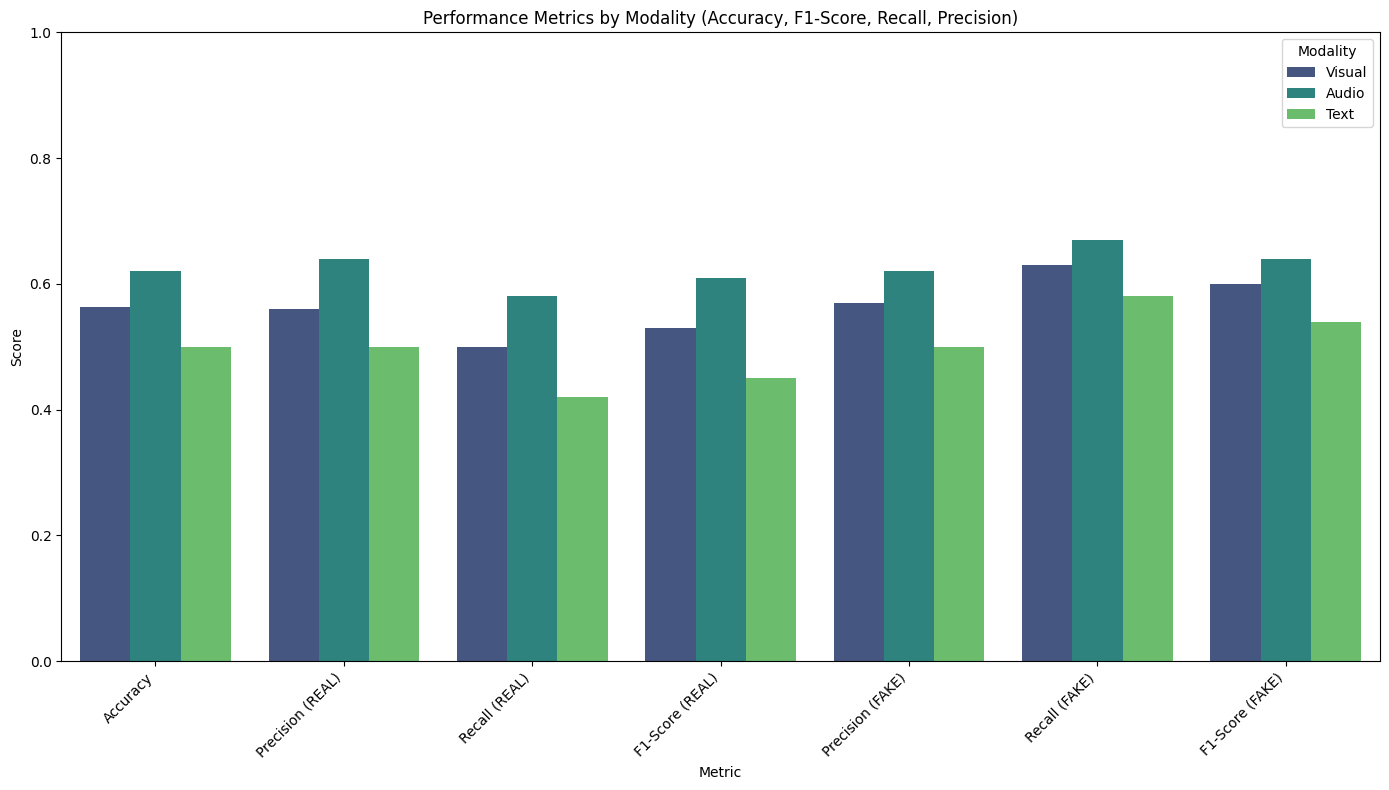

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='viridis')
plt.title('Performance Metrics by Modality (Accuracy, F1-Score, Recall, Precision)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modality')
plt.tight_layout()
plt.show()